# ML Data Preparation

In [1]:
from pathlib import Path
from typing import Dict, List
import io
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_CLEAN_PATH = PROJECT_ROOT / "data/processed/gdelt_benin_clean.csv"
RAW_ML_PATH = PROJECT_ROOT / "data/processed/ml_input_text.csv"
PROCESSED_PATH = PROJECT_ROOT / "data/processed/ml_input_text.csv"
REPORT_PATH = PROJECT_ROOT / "reports/ml_data_prep_summary.txt"

REQUIRED_COLUMNS: List[str] = [
    "SQLDATE",
    "Actor1Name",
    "Actor2Name",
    "EventCode",
    "EventBaseCode",
    "EventRootCode",
    "GoldsteinScale",
    "AvgTone",
    "NumArticles",
    "ActionGeo_FullName",
    "SOURCEURL",
    ]

print('Project root:', PROJECT_ROOT)
print('Using cleaned source:', RAW_CLEAN_PATH)

Project root: /home/appolinaire/projects/benin-insights
Using cleaned source: /home/appolinaire/projects/benin-insights/data/processed/gdelt_benin_clean.csv


In [2]:
if not RAW_CLEAN_PATH.exists():
    raise FileNotFoundError(f"Cleaned source not found: {RAW_CLEAN_PATH}")

df = pd.read_csv(RAW_CLEAN_PATH)

print('FILE:', RAW_CLEAN_PATH)
print('shape:', df.shape)

buf = io.StringIO()
df.info(buf=buf)
print('\n--- df.info() ---')
print(buf.getvalue())

print('\n--- df.describe() ---')
print(df.describe(include='all').transpose())

print('\n--- head(5) ---')
print(df.head(5).to_string(index=False))

print(f"\nmemory_usage (MB): {df.memory_usage(deep=True).sum()/1024**2:.2f}")

FILE: /home/appolinaire/projects/benin-insights/data/processed/gdelt_benin_clean.csv
shape: (5089, 22)

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5089 entries, 0 to 5088
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Actor1Name             5089 non-null   object 
 1   Actor1CountryCode      5089 non-null   object 
 2   Actor2Name             5089 non-null   object 
 3   Actor2CountryCode      5089 non-null   object 
 4   EventCode              5089 non-null   int64  
 5   EventBaseCode          5089 non-null   int64  
 6   EventRootCode          5089 non-null   int64  
 7   GoldsteinScale         5089 non-null   float64
 8   NumArticles            5089 non-null   int64  
 9   AvgTone                5089 non-null   float64
 10  ActionGeo_FullName     5089 non-null   object 
 11  ActionGeo_CountryCode  5089 non-null   object 
 12  ActionGeo_Lat          5089 non-null  

In [3]:
print('1. Période couverte')
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
print(f"  Min: {df['date_parsed'].min()}")
print(f"  Max: {df['date_parsed'].max()}")
print(f"  Durée: {(df['date_parsed'].max() - df['date_parsed'].min()).days} jours")

print('\n2. Distribution du sentiment (sentiment label)')
if 'sentiment' in df.columns:
    print(df['sentiment'].value_counts().sort_index())
else:
    print('  Colonne sentiment non trouvée; colonnes disponibles:', df.columns.tolist())

print('\n3. Top 10 sources (par domaine)')
df['domain'] = df['SOURCEURL'].str.split('/').str[2]
print(df['domain'].value_counts().head(10))

print('\n4. GoldsteinScale distribution (quantiles)')
print(df['GoldsteinScale'].describe())

print('\n5. Corrélation AvgTone (sentiment) vs GoldsteinScale (stabilité)')
corr = df[['AvgTone','GoldsteinScale']].corr()
print(corr)
print(f'\nCorrélation AvgTone-GoldsteinScale: {corr.iloc[0,1]:.3f}')
print('  → Corrélation modérée = deux signaux complémentaires à exploiter')

1. Période couverte
  Min: 2025-01-01 00:00:00
  Max: 2026-05-02 00:00:00
  Durée: 486 jours

2. Distribution du sentiment (sentiment label)
sentiment
neutre      924
négatif    2608
positif    1557
Name: count, dtype: int64

3. Top 10 sources (par domaine)
domain
lanouvelletribune.info      494
saharareporters.com         238
allafrica.com               161
quicknews-africa.net        128
fr.allafrica.com            108
promptnewsonline.com        108
levenementprecis.com         73
www.africatopsuccess.com     73
www.yahoo.com                59
www.africanews.com           58
Name: count, dtype: int64

4. GoldsteinScale distribution (quantiles)
count    5089.000000
mean        0.587542
std         4.567960
min       -10.000000
25%        -2.000000
50%         1.900000
75%         3.400000
max        10.000000
Name: GoldsteinScale, dtype: float64

5. Corrélation AvgTone (sentiment) vs GoldsteinScale (stabilité)


                 AvgTone  GoldsteinScale
AvgTone         1.000000        0.371373
GoldsteinScale  0.371373        1.000000

Corrélation AvgTone-GoldsteinScale: 0.371
  → Corrélation modérée = deux signaux complémentaires à exploiter


# Distribution temporelle mensuelle
Objectif: mesurer le volume par mois et detecter les pics (seuil moyenne + 1 sigma).

=== VOLUME PAR MOIS ===


date_parsed
2025-01    705
2025-02    293
2025-03    322
2025-04    171
2025-05    219
2025-06     75
2025-07     25
2025-10     57
2025-11     73
2025-12    173
2026-01    817
2026-02    791
2026-03    720
2026-04    640
2026-05      8
Freq: M

=== PICS (moy+1σ) ===
date_parsed
2025-01    705
2026-01    817
2026-02    791
2026-03    720
2026-04    640
Freq: M


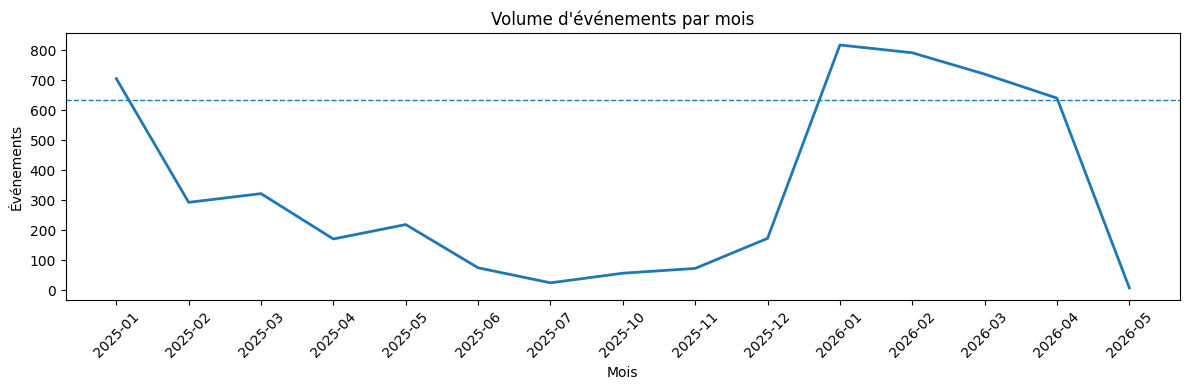

In [4]:
import pandas as pd

if "df" not in globals():
    raise RuntimeError("Exécuter d'abord les cellules 1 et 2 (chargement des données)")

if "date_parsed" not in df.columns:
    if "date" in df.columns:
        date_source = df["date"]
    elif "SQLDATE" in df.columns:
        date_source = df["SQLDATE"]
    else:
        raise ValueError("Colonne date absente (attendues: date, SQLDATE)")
    df["date_parsed"] = pd.to_datetime(date_source, errors="coerce")

if df["date_parsed"].isna().all():
    raise ValueError("Impossible de parser les dates (colonnes attendues: date, SQLDATE)")

year_month = df["date_parsed"].dt.to_period("M")
monthly_counts = year_month.value_counts().sort_index()

threshold: float = float(monthly_counts.mean() + monthly_counts.std(ddof=0))
peaks = monthly_counts[monthly_counts.gt(threshold)]

print("=== VOLUME PAR MOIS ===")
print(monthly_counts.to_string())

print("\n=== PICS (moy+1σ) ===")
print("Aucun" if peaks.empty else peaks.to_string())

try:
    import matplotlib.pyplot as plt

    x = monthly_counts.index.astype(str).tolist()
    y = monthly_counts.values.tolist()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x, y, linewidth=2)
    ax.axhline(threshold, linestyle="--", linewidth=1)
    ax.set_title("Volume d'événements par mois")
    ax.set_xlabel("Mois")
    ax.set_ylabel("Événements")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    plt.show()
    plt.close(fig)
except ImportError:
    raise ImportError("matplotlib manquant. Installe via: pip install -r requirements.txt")

#### Evenements majeurs des mois de pic
Identifier les event_label dominants pour chaque mois de pic et les visualiser.


--- 2025-01 | n=705 ---
event_label
Consultation               199
Déclaration publique       106
Engagement diplomatique     90
Violence de masse           58
Désapprobation              47
Appel / Demande             44
Aide / Assistance           31
Coercition                  19
Rejet / Refus               18
Coopération                 17


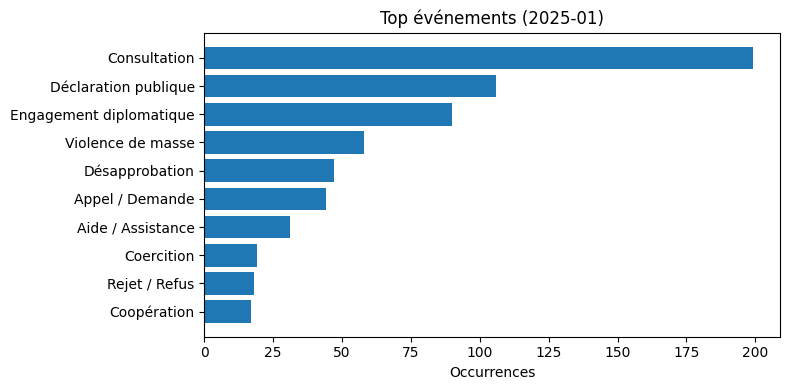


--- 2026-01 | n=817 ---
event_label
Consultation               215
Déclaration publique       121
Engagement diplomatique     96
Appel / Demande             59
Désapprobation              58
Coercition                  41
Accord / Coopération        36
Coopération                 32
Aide / Assistance           26
Violence de masse           24


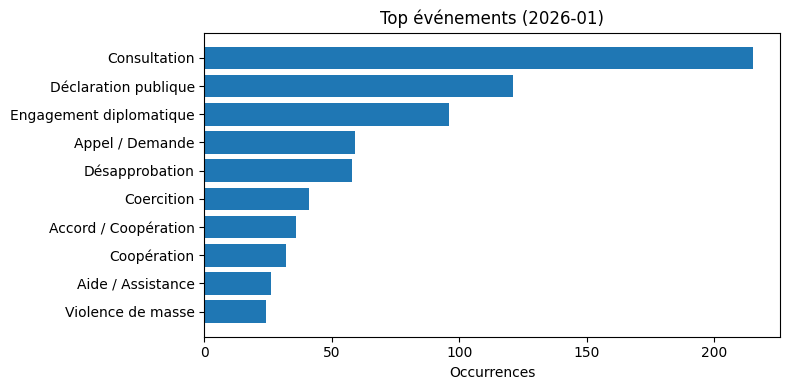


--- 2026-02 | n=791 ---
event_label
Consultation               236
Déclaration publique        99
Engagement diplomatique     75
Désapprobation              68
Violence de masse           58
Appel / Demande             51
Coercition                  33
Accord / Coopération        25
Médiation                   25
Aide / Assistance           24


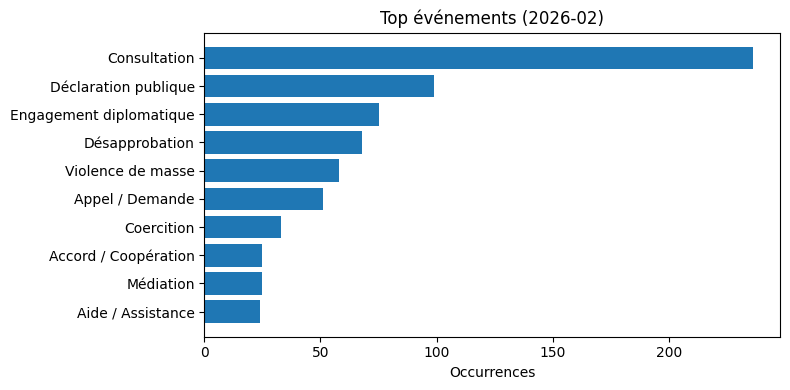


--- 2026-03 | n=720 ---
event_label
Consultation               167
Déclaration publique       113
Engagement diplomatique     90
Appel / Demande             53
Violence de masse           46
Désapprobation              39
Coercition                  27
Coopération                 26
Aide / Assistance           24
Protestation                23


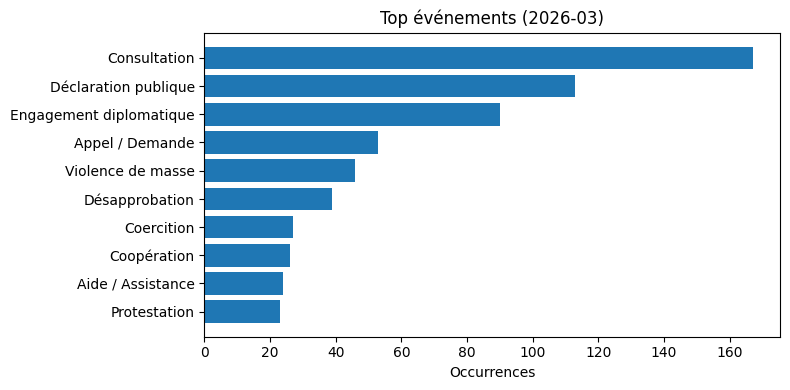


--- 2026-04 | n=640 ---
event_label
Déclaration publique       114
Consultation               112
Engagement diplomatique     89
Coercition                  47
Désapprobation              47
Accord / Coopération        43
Appel / Demande             41
Violence de masse           31
Coopération                 24
Coopération matérielle      17


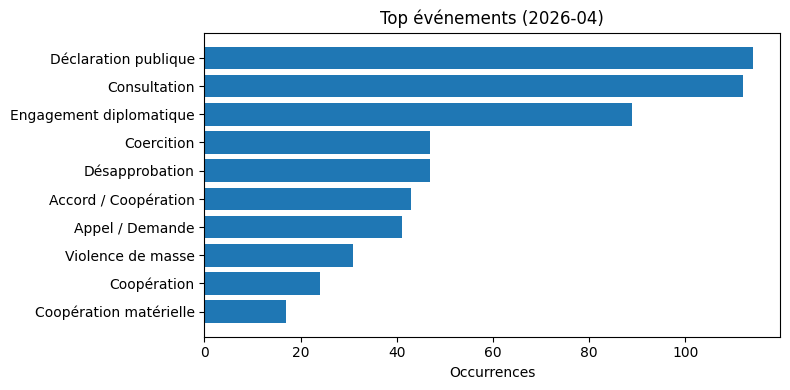

In [5]:
def _pick_first_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None

df_month = df.copy()
df_month["year_month"] = df_month["date_parsed"].dt.to_period("M")

event_col = _pick_first_col(df_month, ["event_label", "EventRootCode", "EventBaseCode", "EventCode"])
if event_col is None:
    raise ValueError("Aucune colonne événement trouvée (event_label, EventRootCode, EventBaseCode, EventCode)")

peak_months = list(peaks.index) if "peaks" in globals() else []
if not peak_months:
    print("Aucun mois de pic")
else:
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        raise ImportError("matplotlib manquant. Installe via: pip install -r requirements.txt")

    for m in peak_months:
        sub = df_month[df_month["year_month"] == m]
        top_events = sub[event_col].value_counts().head(10)

        print(f"\n--- {m} | n={len(sub)} ---")
        print(top_events.to_string())

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.barh(list(reversed(top_events.index.astype(str).tolist())), list(reversed(top_events.values.tolist())))
        ax.set_title(f"Top événements ({m})")
        ax.set_xlabel("Occurrences")
        fig.tight_layout()
        plt.show()
        plt.close(fig)

# Focus compare (2025-01, 2025-06, 2025-07)
Objectif: investiguer le creux de juin 2025 et comparer volumes, sources et event_label dominants.

In [6]:
if "df" not in globals():
    raise RuntimeError("Exécuter d'abord les cellules de chargement des données")

if "date_parsed" not in df.columns:
    date_source = df["date"] if "date" in df.columns else df["SQLDATE"]
    df["date_parsed"] = pd.to_datetime(date_source, errors="coerce")

monthly_period = df["date_parsed"].dt.to_period("M")
month_key = monthly_period.astype(str)

months_to_investigate = ["2025-01", "2025-06", "2025-07"]
months_to_compare = ["2025-05", "2025-06", "2025-07"]

print("=== Comparatif rapide des volumes ===")
volume_compare = (
    df.assign(month=monthly_period)
      .groupby("month")
      .agg(rows=("event_label", "size"),
           articles=("NumArticles", "sum"),
           unique_urls=("SOURCEURL", "nunique"))
      .loc[pd.PeriodIndex(months_to_compare, freq="M")]
)
print(volume_compare)

for month in months_to_investigate:
    sub = df[month_key == month].copy()
    print(f"\n=== {month} | n={len(sub)} | NumArticles={int(sub['NumArticles'].sum())} ===")
    print("event_label dominants:")
    print(sub["event_label"].value_counts().head(8).to_string())
    print("sources dominantes:")
    print(sub["SOURCEURL"].str.split("/").str[2].value_counts().head(5).to_string())
    print("GoldsteinScale:")
    print(sub["GoldsteinScale"].describe().to_string())


=== Comparatif rapide des volumes ===
         rows  articles  unique_urls
2025-05   219      1648          105
2025-06    75       528           42
2025-07    25       166           12

=== 2025-01 | n=705 | NumArticles=4966 ===
event_label dominants:
event_label
Consultation               199
Déclaration publique       106
Engagement diplomatique     90
Violence de masse           58
Désapprobation              47
Appel / Demande             44
Aide / Assistance           31
Coercition                  19
sources dominantes:
SOURCEURL
lanouvelletribune.info    68
www.peoplesdailyng.com    29
levenementprecis.com      23
fr.allafrica.com          17
quicknews-africa.net      16
GoldsteinScale:
count    705.000000
mean       0.580426
std        4.849281
min      -10.000000
25%       -2.000000
50%        1.900000
75%        3.400000
max       10.000000

=== 2025-06 | n=75 | NumArticles=528 ===
event_label dominants:
event_label
Consultation               34
Engagement diplomatique    11

In [7]:
print(df[df['date_parsed'].dt.to_period('M') == '2025-07']['event_label'].value_counts().head(8))

event_label
Consultation               11
Engagement diplomatique     6
Déclaration publique        2
Protestation                2
Coopération                 1
Médiation                   1
Désapprobation              1
Violence de masse           1
Name: count, dtype: int64


# bias_metadata
Documente les biais observes (sources, langue, couverture, limitations NER/topics).

In [8]:
import json

if "date_parsed" not in df.columns:
    date_source = df["date"] if "date" in df.columns else df["SQLDATE"]
    df["date_parsed"] = pd.to_datetime(date_source, errors="coerce")

domains = df["SOURCEURL"].astype(str).str.extract(r"https?://([^/]+)")[0].str.lower() if "SOURCEURL" in df.columns else pd.Series(dtype=str)
top_domains = domains.value_counts().head(10) if not domains.empty else pd.Series(dtype=int)

fr_like = domains.str.contains(r"\.fr$|lemonde|france24|rfi|jeuneafrique|lanouvelletribune|afrique|leparisien|la-croix", regex=True, na=False).mean() * 100 if not domains.empty else 0.0
en_like = domains.str.contains(r"\.ng$|punchng|guardian\.ng|dailypost|thisdaylive|leadership|dailytrust|premiumtimes|allafrica", regex=True, na=False).mean() * 100 if not domains.empty else 0.0

jun_2025_mask = df["date_parsed"].dt.to_period("M").astype(str).eq("2025-06")
jun_rows = int(jun_2025_mask.sum())
total_rows = int(len(df))

bias_metadata = {
    "dataset_rows": total_rows,
    "date_min": str(df["date_parsed"].min()),
    "date_max": str(df["date_parsed"].max()),
    "june_2025_rows": jun_rows,
    "june_2025_share_pct": round((jun_rows / total_rows) * 100, 2) if total_rows else 0.0,
    "source_bias_top_domains": top_domains.to_dict(),
    "language_domain_heuristic": {
        "fr_like_pct": round(float(fr_like), 2),
        "en_like_pct": round(float(en_like), 2),
        "note": "Heuristic from source domains, not article-level language detection.",
    },
    "topic_outlier_pct": round(float((df["topic"] == -1).mean() * 100), 2) if "topic" in df.columns else None,
    "ner_limitations": [
        "Input NER is structured fields concatenated, not natural article text.",
        "en_core_web_sm may miss Benin-specific Francophone and local entities.",
        "Actor placeholders like Inconnu can inject noise.",
    ],
}

print("✓ bias_metadata generated and stored in memory")
print(f"  Dataset: {bias_metadata['dataset_rows']} rows")
print(f"  Date range: {bias_metadata['date_min']} → {bias_metadata['date_max']}")
print(f"  Language heuristic: {bias_metadata['language_domain_heuristic']['fr_like_pct']}% FR-like, {bias_metadata['language_domain_heuristic']['en_like_pct']}% EN-like")

✓ bias_metadata generated and stored in memory
  Dataset: 5089 rows
  Date range: 2025-01-01 00:00:00 → 2026-05-02 00:00:00
  Language heuristic: 13.2% FR-like, 6.31% EN-like
